# MINTERPY/n-dimensional fitting for PG sn2FA using PCO sn2FA fragmentation data as template

In [1]:
# basic python packages
import numpy as np
import pandas as pd

# specific python packages
import minterpy as mp
import cvxpy as cp
# added by Damar for handling equations
import sympy as sp

# visualisation tools
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.widgets  import RectangleSelector
from minterpy.core.utils import get_exponent_matrix
import matplotlib.patches as patches

# others
import minterpy_functions as mf
import pickle

## Import of required data

### Import and conversion of PE sn1FA fragmentation data

In [2]:
# Read PCsym data
data  = pd.read_csv(r"./frag_data/220614_PG_sym-sn1-sn2_FA.csv")

# get sn2 norm_intensity and _var averaged
cols = ['FA_C_y', 'FA_DB_y', 'FA_iso_y', 'sn_y', 'CE']
intensity = data[(data['sn_x'] == 0) & (data['sn_y'] == 1)].groupby(by=cols)['norm_Intensity']
intensity_mean = intensity.mean()

intensity_var = data[(data['sn_x'] == 0) & (data['sn_y'] == 1)].groupby(by=cols)['norm_Intensity_var']
intensity_var_mean = intensity_var.mean()

# df combining the results
df = pd.concat([intensity_mean, intensity_var_mean], axis=1).reset_index()

# renaming of columns
df.columns = ['FA_C', 'FA_DB', 'FA_iso', 'sn_x', 'CE', 'norm_Intensity', 'norm_Intensity_var']

# format for Minterpy
sample_points = df[['CE', 'FA_C', 'FA_DB', 'FA_iso']].to_numpy()
function_vals = df['norm_Intensity'].to_numpy()
# weight_vals = df['norm_Intensity_var'].to_numpy()

print(f"No. of data points in SN2 = {len(function_vals)}")

No. of data points in SN2 = 210


### Visualizing dataset

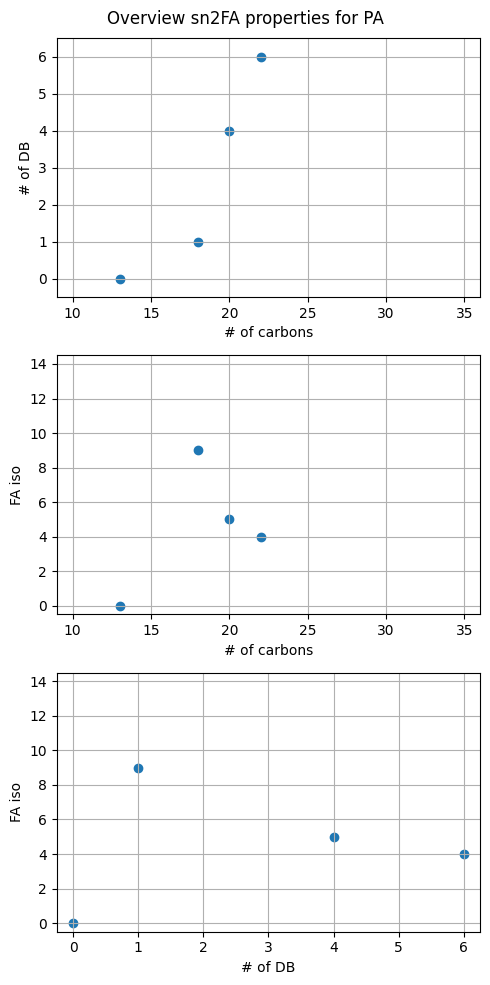

In [3]:
## get dataframe with needed properties
overview_df = df[['FA_C', 'FA_DB', 'FA_iso']].drop_duplicates()

fig, ax = plt.subplots(3,1, figsize=(5,10))

fig.suptitle('Overview sn2FA properties for PA')

# plot number of carbons vs number of DB
ax = plt.subplot(3,1,1)
plt.scatter(overview_df.FA_C, overview_df.FA_DB)
ax.set_xlim(9,36)
ax.set_ylim(-0.5,6.5)
ax.set_xlabel('# of carbons')
ax.set_ylabel('# of DB')
ax.grid(which='both')

# plot number of carbons vs DB position
ax = plt.subplot(3,1,2)
plt.scatter(overview_df.FA_C, overview_df.FA_iso)
ax.set_xlim(9,36)
ax.set_ylim(-0.5,14.5)
ax.set_xlabel('# of carbons')
ax.set_ylabel('FA iso')
ax.grid(which='both')

# plot number of DB vs DB position
ax = plt.subplot(3,1,3)
plt.scatter(overview_df.FA_DB, overview_df.FA_iso)
ax.set_xlim(-0.25,6.25)
ax.set_ylim(-0.5,14.5)
ax.set_xlabel('# of DB')
ax.set_ylabel('FA iso')
ax.grid(which='both')

plt.tight_layout()
plt.show()

## Import of template PCO data

In [4]:
df_pco = pd.read_csv(r"./frag_data/211004_PCO_sn2FA.csv")

df_pco['CE'] = (1.02*df_pco['CE'] - 0)

cols = ['CE', 'FA_C_y', 'FA_DB_y', 'FA_iso_y']

sample_points_pco = df_pco[cols].to_numpy()
function_vals_pco = df_pco['norm_Intensity'].to_numpy()

## MINTERPY/n-dimensional fitting of scaled PCO FA fragment data

PG sn2FA dataset is used for training the polynomial model. For this, the PCO dataset is scaled to match PG and used for fitting with Minterpy.

In [5]:
# Reorganize data for fitting
size_data = function_vals.shape[0] # class of interest
size_pco_data = function_vals_pco.shape[0] # template PCO

size_train_data_wpco = size_data + size_pco_data # total size

train_sample_points = np.vstack([sample_points, sample_points_pco])
train_function_vals = np.zeros(size_train_data_wpco)

# populate train_function_vals with values
train_function_vals[:size_data] = function_vals
# scaling of PCO dataset
scaled_pco_function_vals = function_vals_pco/np.max(function_vals_pco) * np.max(function_vals)

train_function_vals[size_data:] = scaled_pco_function_vals

In [6]:
# actual fitting
sparse_poly_model = mf.lasso_fit_data(train_sample_points,
                                           train_function_vals, 
                                           poly_degree_along=[8,2,2,2], 
                                           weighted=True)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/minterpy/schemes/barycentric/operators.py:47: UserWarning: building a full transformation matrix from a barycentric transformation. this is inefficient.
  warn(


Optimizer result : 335.7094619236208


L_inf error of fitting PCO + dataset of interest = 20.54750833383329


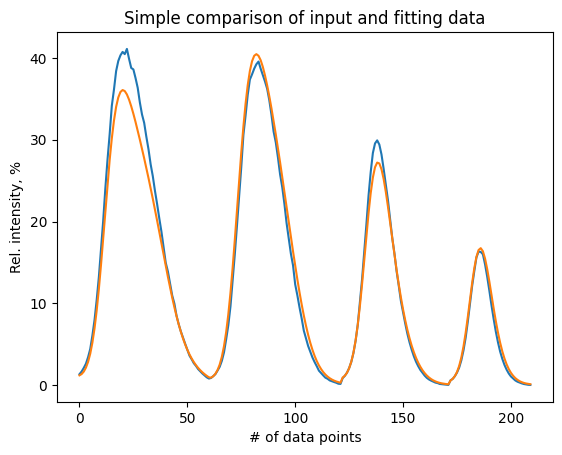

In [7]:
lower_bounds = np.round(np.amin(train_sample_points, axis=0))
upper_bounds = np.round(np.amax(train_sample_points, axis=0))+1.0

eval_vals = mf.poly_evaluate_at(sparse_poly_model, train_sample_points, lower_bounds, upper_bounds) ## here is the calculation of fitted intensity values

abs_errs = pow(2,eval_vals[:size_data]) - train_function_vals[:size_data]
rel_errs = np.divide(abs_errs, train_function_vals[:size_data])
Linf_error = np.max(np.abs(rel_errs))
print(f"L_inf error of fitting PCO + dataset of interest = {Linf_error}")

plt.title("Simple comparison of input and fitting data")
plt.plot(train_function_vals[:size_data])
plt.plot(pow(2,eval_vals[:size_data]))
plt.xlabel("# of data points")
plt.ylabel("Rel. intensity, %")
plt.xlabel("# of data points")
plt.ylabel("Rel. intensity, %")
plt.show()

## Visualization of fitting data/results

### Fragment intensity contour plot for saturated FA

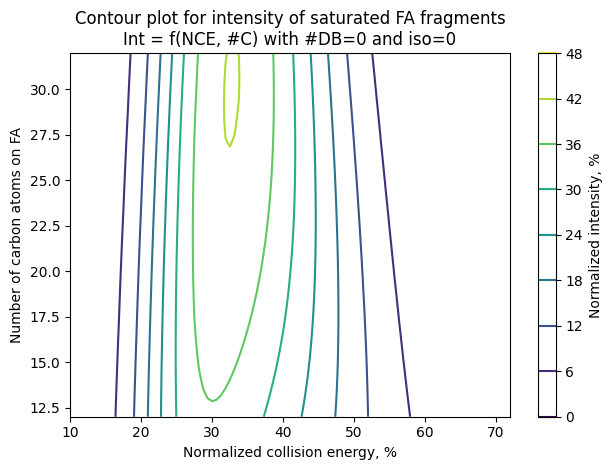

In [8]:
lower_bounds = np.round(np.amin(train_sample_points, axis=0))
upper_bounds = np.round(np.amax(train_sample_points, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 12 #lower_bounds[1]
yhi = 32 #upper_bounds[1]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_db = 0
fa_iso = 0

num_points_in_grid = len(coords_y)
eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x ## NCE
eval_points[:,1] = coords_y ## FA_C
eval_points[:,2] = fa_db
eval_points[:,3] = fa_iso

eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of saturated FA fragments\nInt = f(NCE, #C) with #DB=0 and iso=0")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of carbon atoms on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar().set_label('Normalized intensity, %')

plt.tight_layout()
plt.show()

### Fragment intensity contour plot for polyunsaturated FA

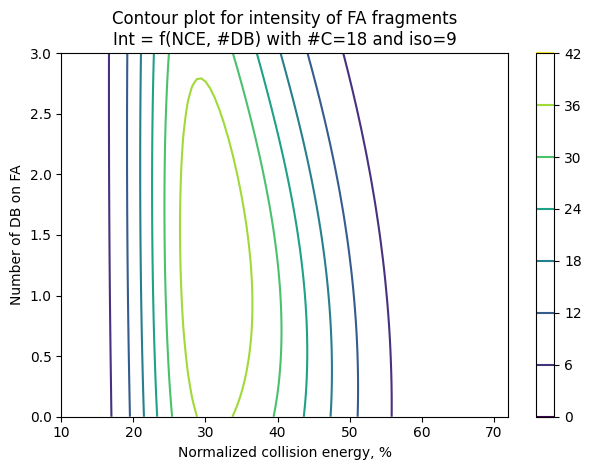

In [9]:
lower_bounds = np.round(np.amin(train_sample_points, axis=0))
upper_bounds = np.round(np.amax(train_sample_points, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 3 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 18
fa_iso = 9

num_points_in_grid = len(coords_y)
eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso

eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of FA fragments\nInt = f(NCE, #DB) with #C=18 and iso=9")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of DB on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar()

plt.tight_layout()
plt.show()

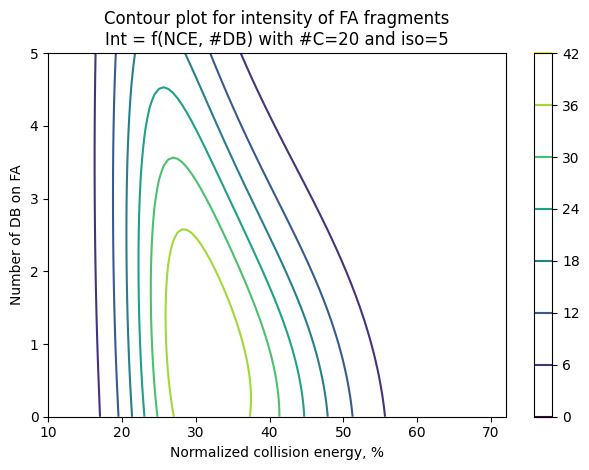

In [10]:
lower_bounds = np.round(np.amin(train_sample_points, axis=0))
upper_bounds = np.round(np.amax(train_sample_points, axis=0))+1.0

xlo = lower_bounds[0]
xhi = upper_bounds[0]
ylo = 0 #lower_bounds[2]
yhi = 5 #upper_bounds[2]

xvals = np.linspace(xlo, xhi, 100)
yvals = np.linspace(ylo, yhi, 100)

# yvals

X,Y = np.meshgrid(xvals, yvals)
coords_x = X.reshape(-1)
coords_y = Y.reshape(-1)

fa_c = 20
fa_iso = 5

num_points_in_grid = len(coords_y)
eval_points = np.zeros((num_points_in_grid, 4))
eval_points[:,0] = coords_x
eval_points[:,1] = fa_c
eval_points[:,2] = coords_y
eval_points[:,3] = fa_iso

eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)

plt.title("Contour plot for intensity of FA fragments\nInt = f(NCE, #DB) with #C=20 and iso=5")
plt.xlabel("Normalized collision energy, %")
plt.ylabel("Number of DB on FA")
plt.contour(X,Y, pow(2,eval_vals.reshape((100,100))))
plt.colorbar()

plt.tight_layout()
plt.show()

### Comparison of fragment intensities : measured vs calculated via MINTERPY/ndim fitting

#### Comparison for saturated FA

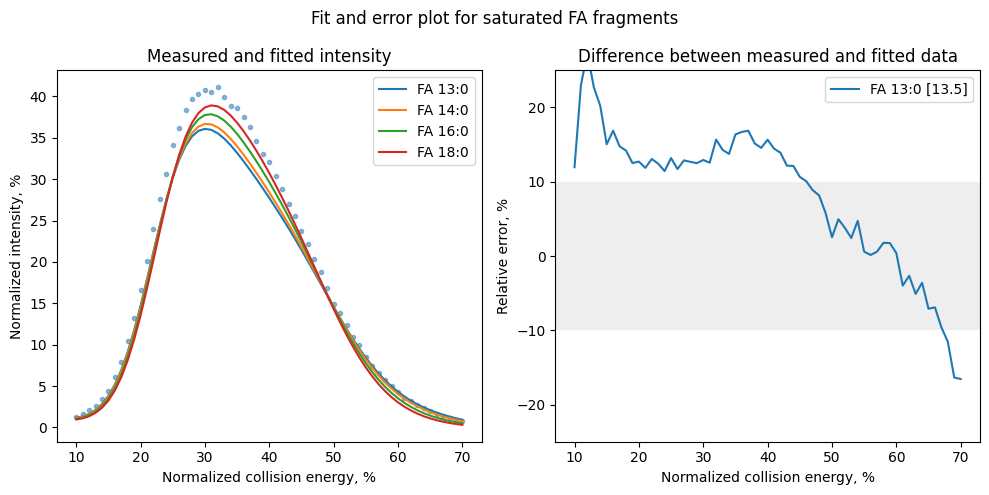

In [11]:
# color definition for plots
colors = [('tab:blue', '#1f77b4'), ('tab:orange', '#ff7f0e'), ('tab:green', '#2ca02c'), ('tab:red', '#d62728'), ('tab:purple', '#9467bd'), ('tab:brown', '#8c564b'), ('tab:pink', '#e377c2'), ('tab:gray', '#7f7f7f'), ('tab:olive', '#bcbd22'), ('tab:cyan', '#17becf')]

nce = [10,70] # range of nce
FA_oi = [[13, 0, 0], [14, 0, 0], [16, 0, 0], [18, 0, 0]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

fig.suptitle("Fit and error plot for saturated FA fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])


# axes label     
ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Comparison for FAs with 18 carbons and different DBs

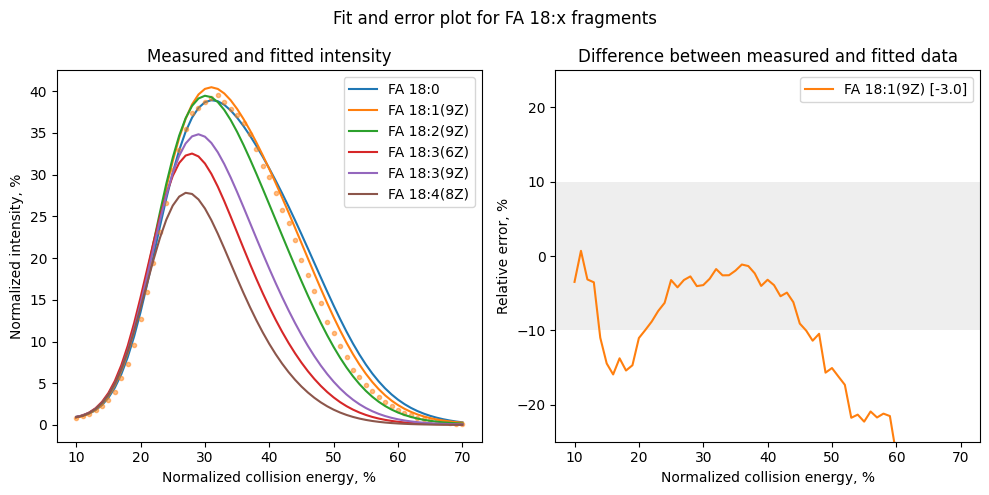

In [12]:
nce = [10,70] # range of nce
FA_oi = [[18, 0, 0], [18, 1, 9], [18, 2, 9], [18, 3, 6], [18, 3, 9], [18, 4, 8]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA 18:x fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Comparison for FAs with 20 carbons and different DBs

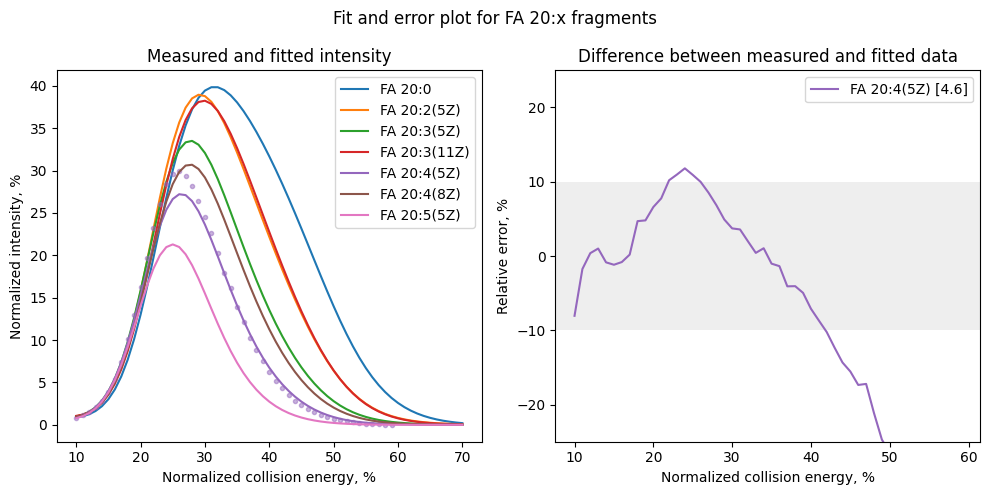

In [13]:
nce = [10,70] # range of nce
FA_oi = [[20, 0, 0], [20, 2, 5], [20, 3, 5], [20, 3, 11], [20, 4, 5], [20, 4, 8], [20, 5, 5]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA 20:x fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Comparison for FAs with 22 carbons and different DBs

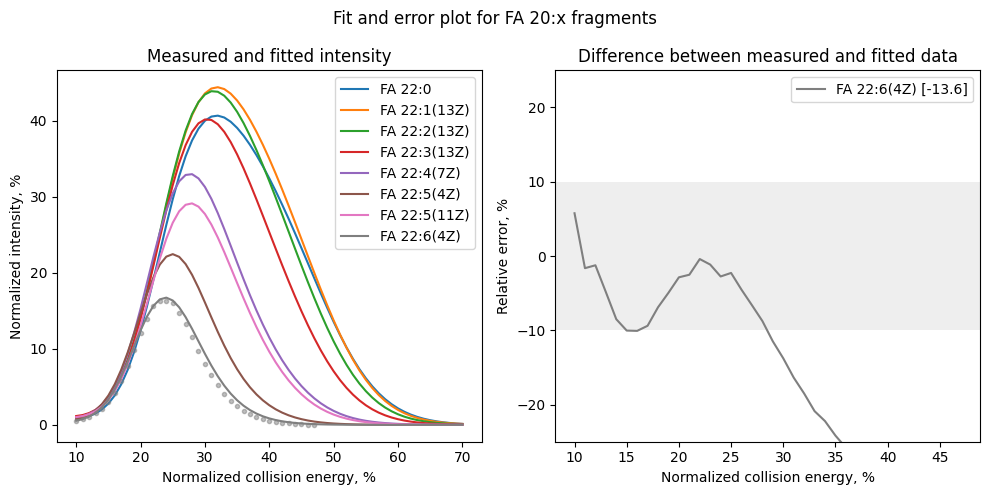

In [14]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 1, 13], [22, 2, 13], [22, 3, 13], [22, 4, 7], [22, 5, 4], [22, 5, 11], [22, 6, 4]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA 20:x fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Comparison for FAs with 22-32 carbons and 6 DBs

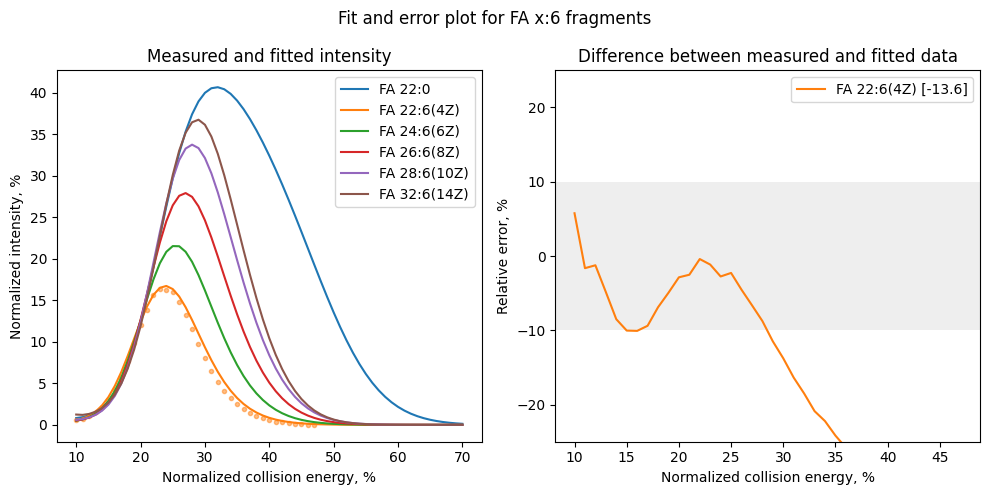

In [15]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 6, 4], [24, 6, 6], [26, 6, 8], [28, 6, 10], [32, 6, 14]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA x:6 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Comparison for main FA with 0-6 DBs

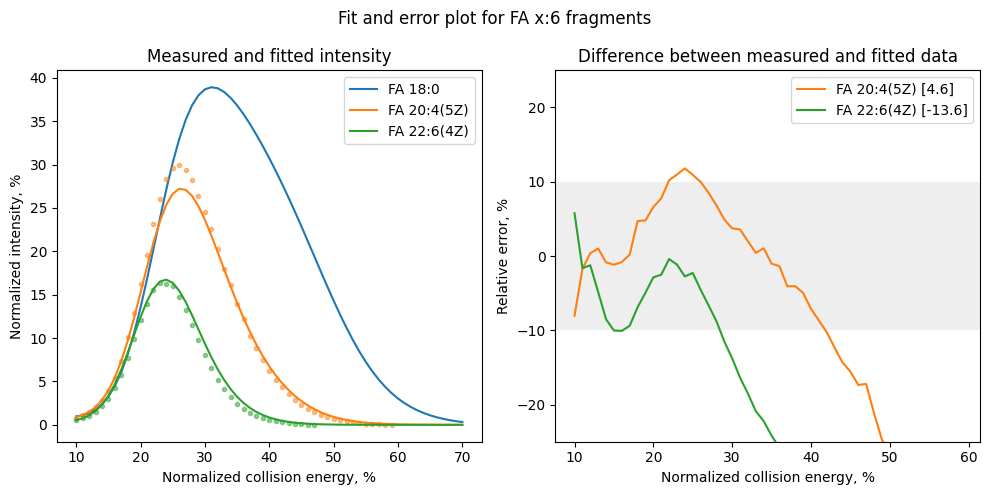

In [16]:
nce = [10,70] # range of nce
FA_oi = [[18, 0, 0], [20, 4, 5], [22, 6, 4]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA x:6 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(25, 36).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Handling MINTERPYs ndim equations

### Convertion of NewtonPolynomials for 'equation' 

In [17]:
# Transformation of NewtonPolynomials to Canonical Form
model_can = mp.get_transformation(sparse_poly_model, mp.CanonicalPolynomial)()

trimmed_coeffs = model_can.coeffs.copy()

# conditional coefficient modification, if needed
# trimmed_coeffs[np.where((trimmed_coeffs<1e0) & (trimmed_coeffs>-1e0))] = 0.0
# trimmed_coeffs = np.around(trimmed_coeffs, 2)

model_can.coeffs = trimmed_coeffs
model_eqn = mf.mp_to_sympy(model_can)

# conversion to equation
model_eqn

Poly(2.46408213988951*x_0**8 - 4.9013900823551e-12*x_0**7*x_1**2*x_2**2*x_3**2 + 1.31846161651715e-13*x_0**7*x_1**2*x_2**2*x_3 - 7.37358505543837e-12*x_0**7*x_1**2*x_2**2 - 2.65433592940741e-11*x_0**7*x_1**2*x_2*x_3**2 + 6.62265628028661e-12*x_0**7*x_1**2*x_2*x_3 - 2.99018244060468e-11*x_0**7*x_1**2*x_2 - 1.05334437202856e-11*x_0**7*x_1**2*x_3**2 - 4.89790826606972e-12*x_0**7*x_1**2*x_3 - 8.15264411471399e-12*x_0**7*x_1**2 + 1.16780297260291e-12*x_0**7*x_1*x_2**2*x_3**2 - 5.88583583543049e-12*x_0**7*x_1*x_2**2*x_3 - 6.19194831312736e-13*x_0**7*x_1*x_2**2 + 2.38264289207404e-12*x_0**7*x_1*x_2*x_3**2 - 1.62169725414129e-12*x_0**7*x_1*x_2*x_3 - 0.261725334950607*x_0**7*x_1*x_2 - 7.09505974725568e-12*x_0**7*x_1*x_3**2 - 1.33147785467241e-12*x_0**7*x_1*x_3 - 0.182944171345773*x_0**7*x_1 - 5.11287732019559e-11*x_0**7*x_2**2*x_3**2 + 3.9711387323112e-11*x_0**7*x_2**2*x_3 + 1.63392229937987e-11*x_0**7*x_2**2 - 1.09635683436003e-11*x_0**7*x_2*x_3**2 - 1.37427898288685*x_0**7*x_2*x_3 - 4.7182062

### Saving/export of polynomial functions as eg pickle

In [18]:
# write polynomial coefficients and exponents to dictionary for export
poly_info = {'coeffs': sparse_poly_model.coeffs, 'exponents': sparse_poly_model.multi_index.exponents, 'lower_bounds': lower_bounds, 'upper_bounds': upper_bounds}

# Storing the polynomial object in a file
pickle.dump(poly_info, open(r'./polynomials/240927_PG_sn2FA_poly.pkl', 'ab'))

In [19]:
poly_info

{'coeffs': array([-2.51420789e+01, -1.42798636e+01, -2.69736962e+00,  1.21360113e+01,
        -1.31942601e+00,  4.67964523e+00,  3.36505697e+00, -2.28340649e+00,
         2.46408214e+00, -4.46448338e-01,  1.67645772e+00, -5.71964455e+00,
        -2.26071077e+00, -2.11324608e-01, -1.83614372e+00,  2.01312737e-01,
        -4.44669506e-01,  1.96827760e+00,  3.19091256e-01,  1.03672857e-01,
        -1.74894765e-10, -3.60361962e-10, -8.60502780e-11, -4.17585966e-11,
        -8.92446117e-11, -1.24107390e+01, -6.98951905e+00,  1.00872491e+00,
         5.37593499e+00, -9.38124945e-02,  3.07209471e+00, -4.70997406e-02,
         1.63600432e+00,  1.98597846e+00,  1.76814137e+00, -1.51841038e+00,
        -2.50659296e-01,  5.93074478e-11, -4.30916790e-01,  1.68860481e-11,
        -2.61725335e-01,  1.16686423e+00,  2.25744667e-01,  1.03672857e-01,
        -5.57526136e-10, -1.68675074e-11, -3.24084759e-10, -6.93134439e-12,
        -6.30593355e-11, -4.50896267e+00, -3.09685143e+00,  1.38245874e+00,
  

## Build a template of [FA]- and [FA+CO2NL]- intensities for PG sn1 CO2NL calculation

In [20]:
## import list of CO2NL species
CO2NLspecies = pickle.load(open('./helper/CO2NL_species.pkl', 'rb'))
## import of CO2NL template data from PAsn2; this are normalized intensity data
CO2NL_int = pickle.load(open('./helper/CO2NL_PGsn2_template.pkl', 'rb'))
##  PCO FAs in an array
FAspecies = pickle.load(open('./helper/FA_CO2NL_items.pkl', 'rb'))

In [21]:
# Define lower and upper bounds based on training sample points
lower_bounds = np.round(np.amin(train_sample_points, axis=0))
upper_bounds = np.round(np.amax(train_sample_points, axis=0)) + 1.0

# Initialize list to store data for each FA species
data_l = []

# Loop through FA species to create template data
for i in FAspecies:
    num_points_in_grid = int(upper_bounds[0] - lower_bounds[0]) + 1

    # Generate evenly spaced x-values (NCE)
    xvals = np.linspace(lower_bounds[0], upper_bounds[0], num_points_in_grid)

    # Create evaluation points array with shape (num_points_in_grid, 4)
    eval_points = np.zeros((num_points_in_grid, 4))
    eval_points[:, 0] = xvals  # NCE
    eval_points[:, 1] = i[0]   # FA_C (carbon count)
    eval_points[:, 2] = i[1]   # FA_DB (double bonds)
    eval_points[:, 3] = i[2]   # FA_iso (isotope)

    # Evaluate the intensity using the model
    intensity = pd.DataFrame(2 ** mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds))
    
    # Combine eval_points with the corresponding intensities
    data = pd.DataFrame(eval_points)
    data_l.append(pd.concat([data, intensity], axis=1))

# Concatenate all species data into a single DataFrame
pgsn2_FA_template_df = pd.concat(data_l).reset_index(drop=True)

# Rename columns
pgsn2_FA_template_df.columns = ['CE', 'FA_C', 'FA_DB', 'FA_iso', 'norm_Intensity']

# Add 'Type' column for PAsn2 intensity data
pgsn2_FA_template_df['Type'] = 0  # All entries are of Type 0 (PAsn2)

# Set 'Type' for CO2NL intensity data to 1
CO2NL_int['Type'] = 1

# Combine PAsn2 and CO2NL intensity data
tmp = pd.concat([pgsn2_FA_template_df, CO2NL_int], axis=0).reset_index(drop=True)

# Sum the intensities for FA- and CO2NL- groups
FA_CO2_sum = tmp.groupby(['CE', 'FA_C', 'FA_DB', 'FA_iso']).norm_Intensity.sum().reset_index()

# Add 'Type' column for summed data
FA_CO2_sum['Type'] = 1

# Combine summed FA_CO2 data with the original PGsn2 data
FA_CO2_PGsn2_template = pd.concat([FA_CO2_sum, pgsn2_FA_template_df], axis=0)

# # Check the combined data for specific FA_C and CE values
# FA_CO2_PGsn2_template[(FA_CO2_PGsn2_template['FA_C'] == 22) & (FA_CO2_PGsn2_template['CE'] == 35)]


In [22]:
## Export of PG template containing [FA]- and [FA+CO2NL]- intensity data
pickle.dump(FA_CO2_PGsn2_template, open('./helper/FA_CO2NL_PGsn2_template.pkl', 'wb'))